Inputs shape: (28, 4)
Outputs shape: (28,)
First 20 rows of raw data:
       var-1     var-2     var-3     var-4        yield  source
26  0.353188  0.520322  1.112618  1.186113  6717.039991  week-7
25  0.797599  0.775484  1.047075  1.122867  6619.923796  week-6
24  0.263058  0.962540  0.979484  1.057644  4564.328857  week-5
27  0.287950  0.950000  0.950000  1.050000  3942.207447  week-8
22  0.272727  0.848484  0.848485  0.818182  1118.872547  week-3
15  0.224189  0.846480  0.879484  0.878516  1088.859618    file
20  0.183674  0.857143  0.816327  0.877551   872.307487  week-1
21  0.272727  0.848484  0.848485  0.818182   743.118248  week-2
18  0.119879  0.862540  0.643331  0.849804   431.612757    file
23  0.242085  0.848724  0.469207  0.893286   386.681874  week-4
14  0.438933  0.774092  0.378167  0.933696   355.806818    file
4   0.836478  0.193610  0.663893  0.785649   258.370525    file
9   0.463442  0.630025  0.107906  0.957644   233.223610    file
7   0.352356  0.322242  0.116979  

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


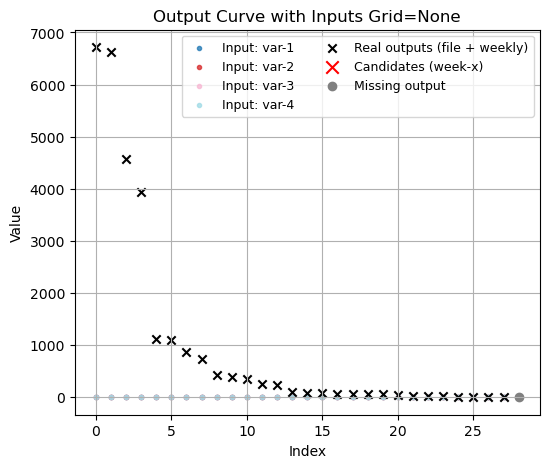

Saved LLM candidates to: results/run_2025-12-22 11-56-34/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))